# Task 4 — Replicate-aware Differential Expression and Pathway Interpretation

**本 notebook 回答：observed perturbation 到底改变了哪些基因和通路？**

核心方法：**pseudobulk + count-based DEG（pydeseq2）+ Hallmark 富集**。

- Q1 Nutlin-3a 与 Vorinostat 分别诱导了哪些可重复的 transcriptional programs？
- Q2 是否 dose-dependent？
- Q3 两者相似/不同在哪？
- Q4 是否与已知药理机制一致？
- Q5 Task 3 的 magnitude/direction 能否被 pathway 解释？

**本 Task 不做**：scGen / CPA / 深度学习 / 未见药物预测 / Virtual Cell（Task 5）。


## 1. 读取 Task 3 结果 + 核对 metadata

### What are we doing?
读取 Task 3 保存的对象，确认 raw counts、normalized 数据、metadata 位置。


In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("data") if Path("data").exists() else Path("..") / "data"
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
RES_DIR = Path("results") / "task4"; RES_DIR.mkdir(parents=True, exist_ok=True)
sc.settings.set_figure_params(dpi=100, dpi_save=300, frameon=False)
sc.settings.figdir = str(FIG_DIR)

adata = sc.read_h5ad(DATA_DIR / "processed" / "adata_perturbation_landscape.h5ad")
adata


AnnData object with n_obs × n_vars = 23628 × 58347
    obs: 'ncounts', 'hash_umis', 'pval_demultiplexing', 'qval_demultiplexing', 'top_to_second_best_ratio', 'top_oligo', 'perturbation', 'dose_value', 'well', 'celltype', 'cell_line', 'cancer', 'disease', 'tissue_type', 'organism', 'perturbation_type', 'ngenes', 'percent_mito', 'percent_ribo', 'nperts', 'chembl-ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'rep_idx', 'is_treated', 'leiden'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'dose_value_colors', 'hvg', 'is_treated_colors', 'leiden', 'leiden_colors', 'log1p', 'n

In [2]:
adata.shape


(23628, 58347)

In [3]:
adata.obs.columns.tolist()


['ncounts',
 'hash_umis',
 'pval_demultiplexing',
 'qval_demultiplexing',
 'top_to_second_best_ratio',
 'top_oligo',
 'perturbation',
 'dose_value',
 'well',
 'celltype',
 'cell_line',
 'cancer',
 'disease',
 'tissue_type',
 'organism',
 'perturbation_type',
 'ngenes',
 'percent_mito',
 'percent_ribo',
 'nperts',
 'chembl-ID',
 'n_genes_by_counts',
 'log1p_n_genes_by_counts',
 'total_counts',
 'log1p_total_counts',
 'pct_counts_in_top_50_genes',
 'pct_counts_in_top_100_genes',
 'pct_counts_in_top_200_genes',
 'pct_counts_in_top_500_genes',
 'total_counts_mt',
 'log1p_total_counts_mt',
 'pct_counts_mt',
 'rep_idx',
 'is_treated',
 'leiden']

In [4]:
list(adata.layers.keys()), adata.raw


(['counts'], None)

### What does the output mean?

- **drug**：`obs['perturbation']`（Dex / Nutlin / SAHA / BMS / control）
- **dose**：`obs['dose_value']`（0–100 µM，control 为 NaN）
- **replicate**：`obs['well']`（每个 drug×dose 有 6 个 well）
- **control/vehicle**：`dose_value == 0`（hashtag 处理的零剂量，= 溶剂对照；未 hash 的 `perturbation=='control'` 深度偏浅且无 replicate，不用于正式 DEG）
- **raw counts**：`adata.layers['counts']`（整数，pseudobulk DEG 用这个）
- **normalized/log**：`adata.X`（log1p 归一化，仅供可视化）


## 2. Experimental design 检查（定 DEG 剂量）

### What are we doing?
统计每个 drug×dose 的细胞数和 replicate 数。

### Why does it matter?
DEG 需要足够的 replicate 和细胞；高剂量可能细胞太少（毒性），不适合做可靠 DEG。


In [4]:
cnt = adata.obs.groupby(['perturbation', 'dose_value'], observed=True).size().unstack(fill_value=0)
print("每个 (drug, dose) 的 well 数（replicate）:")
print(adata.obs.dropna(subset=['dose_value']).groupby(['perturbation','dose_value'], observed=True)['well'].nunique().iloc[:4].to_string())
print("\n细胞数表（重点看 Nutlin / SAHA / control）:")
cnt


每个 (drug, dose) 的 well 数（replicate）:
perturbation  dose_value
BMS           0             6
              0.1           6
              0.5           6
              1             6

细胞数表（重点看 Nutlin / SAHA / control）:


dose_value,0,0.1,0.5,1,5,10,50,100
perturbation,,,,,,,,
BMS,959,902,703,506,435,292,137,126
Dex,886,897,824,1031,992,882,1115,1257
Nutlin,976,833,768,874,811,1069,395,80
SAHA,983,767,692,639,518,523,717,518


### What does the output mean?

- 每个 (drug, dose) 都有 **6 个 replicate（well）**，完整。
- **Nutlin dose=100 只有 80 个细胞**（毒性太强），dose=10 有 1069 → 选 **10 µM 作为 Nutlin 的「高剂量」**。
- **SAHA** 各剂量细胞数较均衡（518–983），也选 **10 µM**，便于两药同剂量对比。
- 未 hash 的 `control` 无 well（无 replicate），且深度偏浅 → **不作为 DEG 的对照**，用各药自己的 `dose=0` 当 vehicle。

**可靠 comparison**：Nutlin 10µM vs 0；SAHA 10µM vs 0（各 6 vs 6 replicate）。更高剂量（50/100µM）因细胞太少或毒性，只能探索性看。

## 3. 什么是 pseudobulk？为什么必须用它

### What are we doing?
把每个 `drug × dose × well` 内所有细胞的 **raw counts 相加**，得到一个 `sample × gene` 的表达矩阵。

### Why does it matter?（核心概念）
- **问题**：单细胞数据里，同一个 well 里的几千个细胞共享培养环境，**彼此不独立**。如果把每个 cell 当独立样本做统计，会人为放大样本量，得到假得离谱的小 p-value。
- **pseudobulk 解法**：把细胞聚合到 **well（replicate）层面**，让统计单位变成「生物学重复」，而不是「细胞」。这样 n = 6（replicate），而不是 n = 几千。
- **必须用 raw counts**：count-based 模型（负二项）需要整数 counts，不能对 log 归一化的值做。

### What could go wrong?
细胞数太少的 well 聚合出的 pseudobulk 噪声大；所以前面排除了 dose=100 这种细胞数骤减的条件。


In [5]:
# 构建 pseudobulk：每个 (drug, dose, well) 一个 sample，raw counts 相加
counts = adata.layers['counts']
obs = adata.obs
dose_list = ['0', '0.1', '0.5', '1', '5', '10', '50', '100']

pb_rows, pb_meta = [], []
for drug in ['Dex', 'Nutlin', 'BMS', 'SAHA']:
    for dose in dose_list:
        m = (obs['perturbation'] == drug) & (obs['dose_value'].astype(str) == dose)
        if m.sum() == 0:
            continue
        for well in sorted(obs.loc[m, 'well'].unique()):
            mw = m & (obs['well'] == well)
            row = np.asarray(counts[mw.values, :].sum(axis=0)).ravel()
            pb_rows.append(row)
            pb_meta.append({'drug': drug, 'dose': float(dose), 'well': well})

pb = pd.DataFrame(np.vstack(pb_rows), columns=adata.var_names)
pb_meta = pd.DataFrame(pb_meta)
pb_meta['sample'] = pb_meta['drug'] + '_' + pb_meta['dose'].astype(str) + '_' + pb_meta['well']
pb.index = pb_meta['sample'].values
pb_meta.index = pb_meta['sample'].values

print("pseudobulk shape（sample × gene）:", pb.shape)
print("每个 sample 的 library size（总 counts）: median =", int(pb.sum(axis=1).median()))
pb_meta.head()


pseudobulk shape（sample × gene）: (192, 58347)
每个 sample 的 library size（总 counts）: median = 652739


,drug,dose,well,sample
Dex_0.0_AC08,Dex,0.0,AC08,Dex_0.0_AC08
Dex_0.0_AD04,Dex,0.0,AD04,Dex_0.0_AD04
Dex_0.0_AD12,Dex,0.0,AD12,Dex_0.0_AD12
Dex_0.0_BC08,Dex,0.0,BC08,Dex_0.0_BC08
Dex_0.0_BD04,Dex,0.0,BD04,Dex_0.0_BD04


### What does the output mean?

- pseudobulk 矩阵是 **192 samples × 58347 genes**（= 4 药 × 8 剂量 × 6 well）。
- 每个 sample 的 library size 中位数约几十万 counts（多细胞聚合）。
- 行名（sample ID）格式如 `Nutlin_10.0_BC07`，方便追踪。

In [6]:
# 保存 pseudobulk 元数据
pb_meta.to_csv(RES_DIR / "pseudobulk_metadata.csv")
print("saved pseudobulk_metadata.csv")


saved pseudobulk_metadata.csv


## 4. DEG 方法：pydeseq2（count-based）

### Why is this method appropriate?
- **负二项分布**：counts 数据的方差随均值增大（overdispersion），DESeq2 显式建模这一点；而直接对 normalized 表达做 t-test 会低估高表达基因的方差、高估低表达基因的显著性。
- **replicate-aware**：pydeseq2 用 6 vs 6 个 replicate 估计生物学变异，而不是把几千个 cell 当独立样本。

### 两个关键概念
- **log2FC**：处理组 vs 对照组表达量的对数倍数变化（effect size，反映「变多大」）。
- **adjusted p-value（padj）**：多重检验校正后的显著性（反映「多可靠」）。**两者是不同概念**——一个基因可以 log2FC 很大但不显著（replicate 不一致），也可以显著但 log2FC 很小（变化微弱）。


In [7]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

def run_deg(pb, pb_meta, drug, dose):
    """对 drug 的 dose 与 dose=0 做 pseudobulk DEG，返回 results_df"""
    sub_meta = pb_meta[(pb_meta['drug'] == drug) & (pb_meta['dose'].isin([0.0, dose]))].copy()
    sub_counts = pb.loc[sub_meta.index].astype(int)
    sub_meta['condition'] = np.where(sub_meta['dose'] == dose, 'treated', 'control')
    dds = DeseqDataSet(counts=sub_counts, metadata=sub_meta[['condition']],
                       design_factors="condition", refit_cooks=True, n_cpus=1, quiet=True)
    dds.deseq2()
    st = DeseqStats(dds, contrast=["condition", "treated", "control"], n_cpus=1, quiet=True)
    st.summary()
    return st.results_df

# 两个核心 comparison（各 6 vs 6 replicate）
res_nut = run_deg(pb, pb_meta, 'Nutlin', 10.0)
res_saha = run_deg(pb, pb_meta, 'SAHA', 10.0)
print("Nutlin 10µM DEG (padj<0.05):", (res_nut['padj'] < 0.05).sum())
print("SAHA  10µM DEG (padj<0.05):", (res_saha['padj'] < 0.05).sum())


Nutlin 10µM DEG (padj<0.05): 2824
SAHA  10µM DEG (padj<0.05): 7405


### What does the output show?

两个药的 DEG 数量。接下来加 effect size 阈值（|log2FC|）筛出「既显著又变化大」的基因。

In [8]:
# 统一加 effect size 阈值，得到「显著 + 强变化」的基因集
def deg_filter(res, padj=0.05, lfc=1.0):
    r = res.dropna(subset=['padj']).copy()
    return r[(r['padj'] < padj) & (r['log2FoldChange'].abs() > lfc)]

nut_sig = deg_filter(res_nut)
saha_sig = deg_filter(res_saha)
print("Nutlin 显著且 |log2FC|>1:", nut_sig.shape[0])
print("SAHA  显著且 |log2FC|>1:", saha_sig.shape[0])


Nutlin 显著且 |log2FC|>1: 977
SAHA  显著且 |log2FC|>1: 4290


## Figure 4-1 / 4-2 — Volcano plots

### What are we doing?
画 Nutlin / SAHA 的 volcano（x=log2FC, y=-log10 padj），标注少量关键基因。

### What can we conclude / NOT conclude?
volcano 直观展示「哪些基因显著且变化大」；但显著 ≠ 重要（要结合 effect size、机制、dose 一致性）。


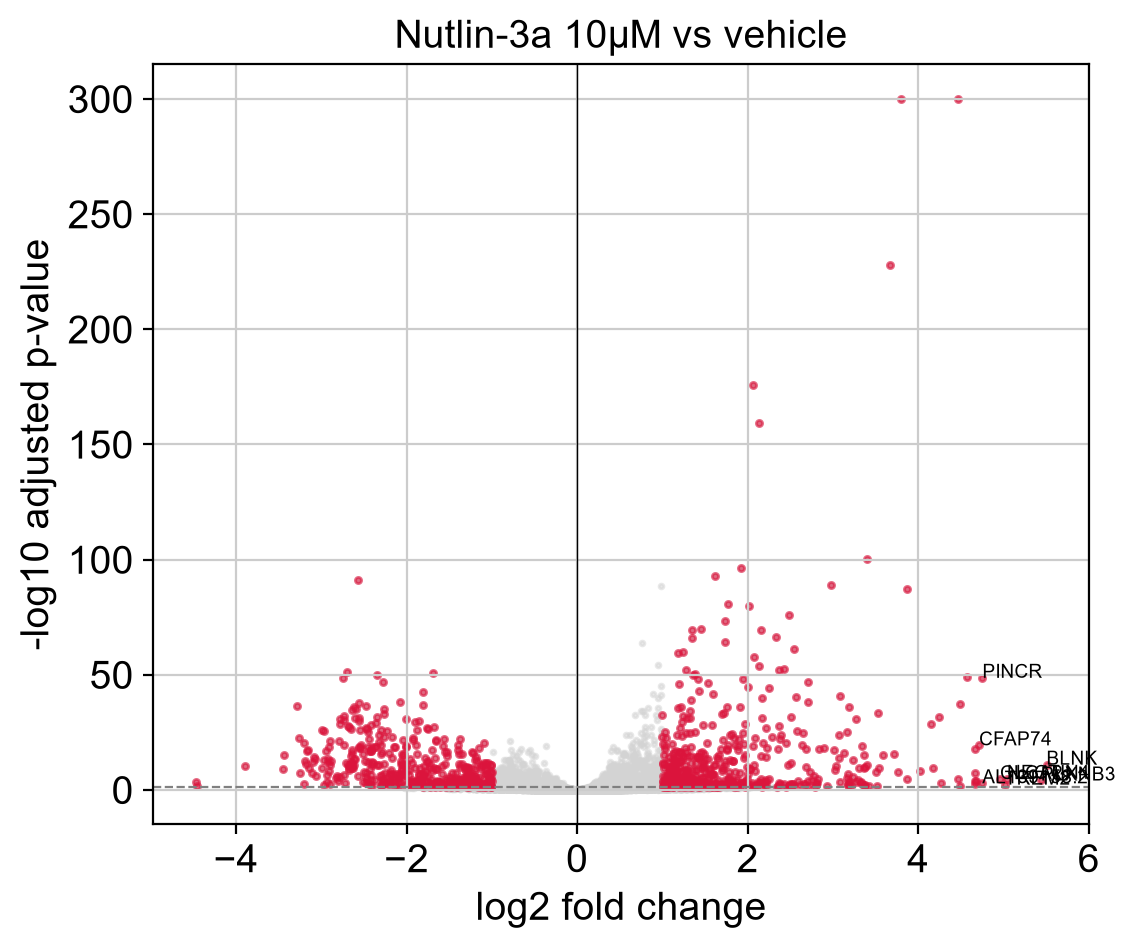

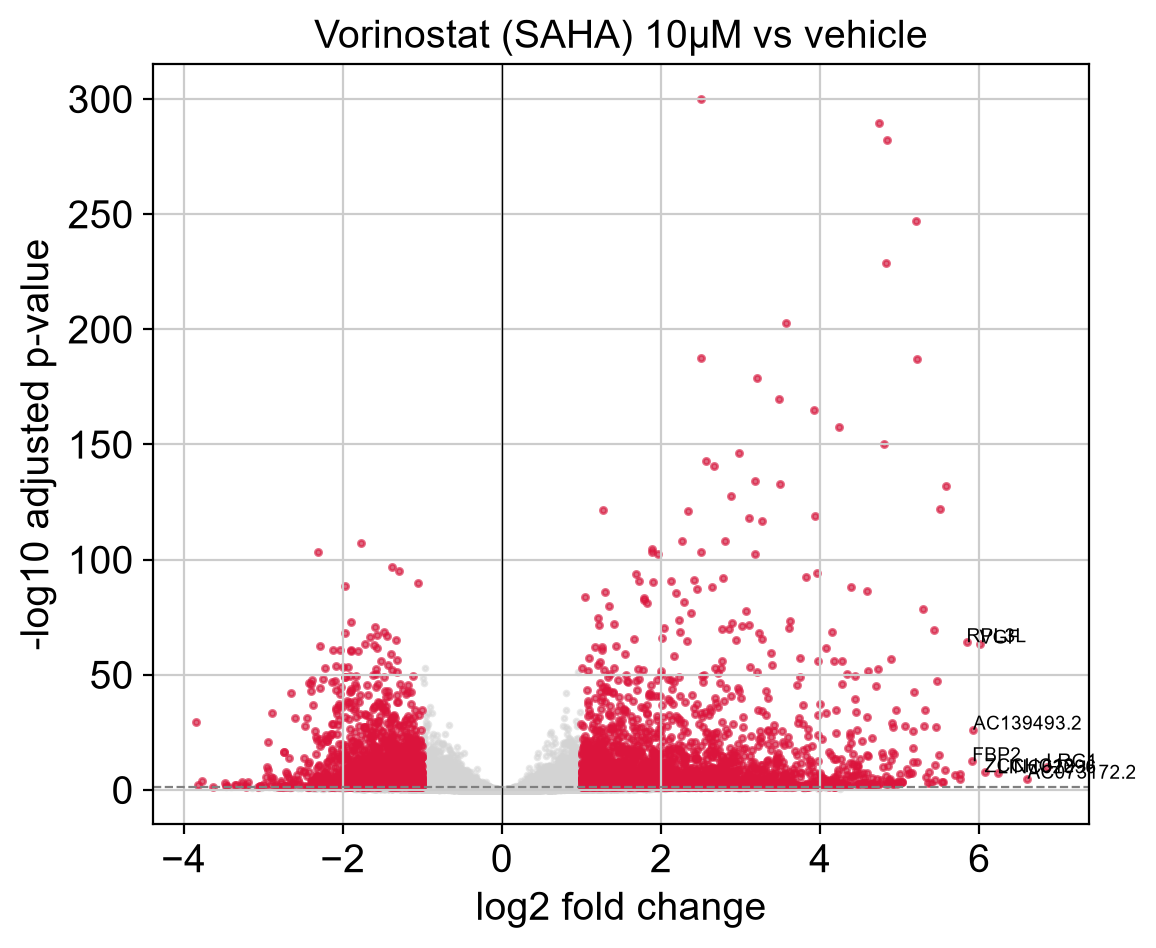

In [9]:
def volcano(res, title, fname, n_label=8):
    r = res.dropna(subset=['padj']).copy()
    r['mlp'] = -np.log10(r['padj'].clip(lower=1e-300))
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(r['log2FoldChange'], r['mlp'], s=3, c='lightgray', alpha=0.5)
    sig = r[(r['padj'] < 0.05) & (r['log2FoldChange'].abs() > 1)]
    ax.scatter(sig['log2FoldChange'], sig['mlp'], s=5, c='crimson', alpha=0.6)
    ax.axvline(0, color='k', lw=0.5)
    ax.axhline(-np.log10(0.05), color='gray', ls='--', lw=0.8)
    # 标注 |log2FC| 最大的几个
    top = sig.reindex(sig['log2FoldChange'].abs().sort_values(ascending=False).index).head(n_label)
    for g, row in top.iterrows():
        ax.annotate(g, (row['log2FoldChange'], row['mlp']), fontsize=7)
    ax.set_xlabel('log2 fold change'); ax.set_ylabel('-log10 adjusted p-value')
    ax.set_title(title)
    fig.savefig(FIG_DIR / fname, dpi=300, bbox_inches='tight')
    plt.show()

volcano(res_nut, 'Nutlin-3a 10µM vs vehicle', 'task4_nutlin_volcano.png')
volcano(res_saha, 'Vorinostat (SAHA) 10µM vs vehicle', 'task4_vorinostat_volcano.png')


### What does the output show?

- 红点 = padj<0.05 且 |log2FC|>1 的基因；灰点 = 不显著或变化小。
- 标注的是变化最剧烈的基因。

In [11]:
# Top DEG 表（up / down 分开）
def top_deg_table(res, n=10):
    r = deg_filter(res)
    up = r[r['log2FoldChange'] > 0].sort_values('log2FoldChange', ascending=False).head(n)
    dn = r[r['log2FoldChange'] < 0].sort_values('log2FoldChange').head(n)
    return pd.concat([up, dn])[['log2FoldChange', 'padj']]

print("=== Nutlin Top DEG (up/down) ===")
top_deg_table(res_nut)


=== Nutlin Top DEG (up/down) ===


,log2FoldChange,padj
gene_symbol,,
BLNK,5.505137,1.122892e-11
PLXNB3,5.438273,8.174354e-05
NECTIN4,5.041888,1.549143e-05
TREM2,5.013909,5.077743e-03
CLCA2,4.959892,2.156004e-05
PINCR,4.753848,2.176765e-49
AL139158.2,4.751545,1.324906e-03
CFAP74,4.714547,4.548481e-20
CYGB,4.679333,9.006097e-05


In [12]:
print("=== SAHA Top DEG (up/down) ===")
top_deg_table(res_saha)


=== SAHA Top DEG (up/down) ===


,log2FoldChange,padj
gene_symbol,,
LRG1,6.844625,1.861500e-10
AC073172.2,6.605764,1.409379e-05
LINC02096,6.229229,6.407337e-08
ZCCHC12,6.066261,2.049120e-08
VGF,6.003247,3.090015e-64
AC139493.2,5.921322,6.683640e-27
FBP2,5.911771,3.545871e-13
RPL3L,5.839788,7.284617e-65
AZGP1,5.761456,1.117841e-05


In [13]:
# 保存 DEG 表
res_nut.to_csv(RES_DIR / "nutlin_deg.csv")
res_saha.to_csv(RES_DIR / "vorinostat_deg.csv")
print("saved nutlin_deg.csv / vorinostat_deg.csv")


saved nutlin_deg.csv / vorinostat_deg.csv


## Figure 4-3 — Dose-dependent gene trajectories

### What are we doing?
对每个药选 8 个代表基因（4 个最强上调 + 4 个最强下调，来自 DEG），画它们在每个剂量下的 pseudobulk 表达（CPM，log2）。

### Why does it matter?
看基因响应是否随 dose 逐步变化（而非 high-dose 偶然差异）。每个点是一个 well（replicate），能看到 replicate 一致性。


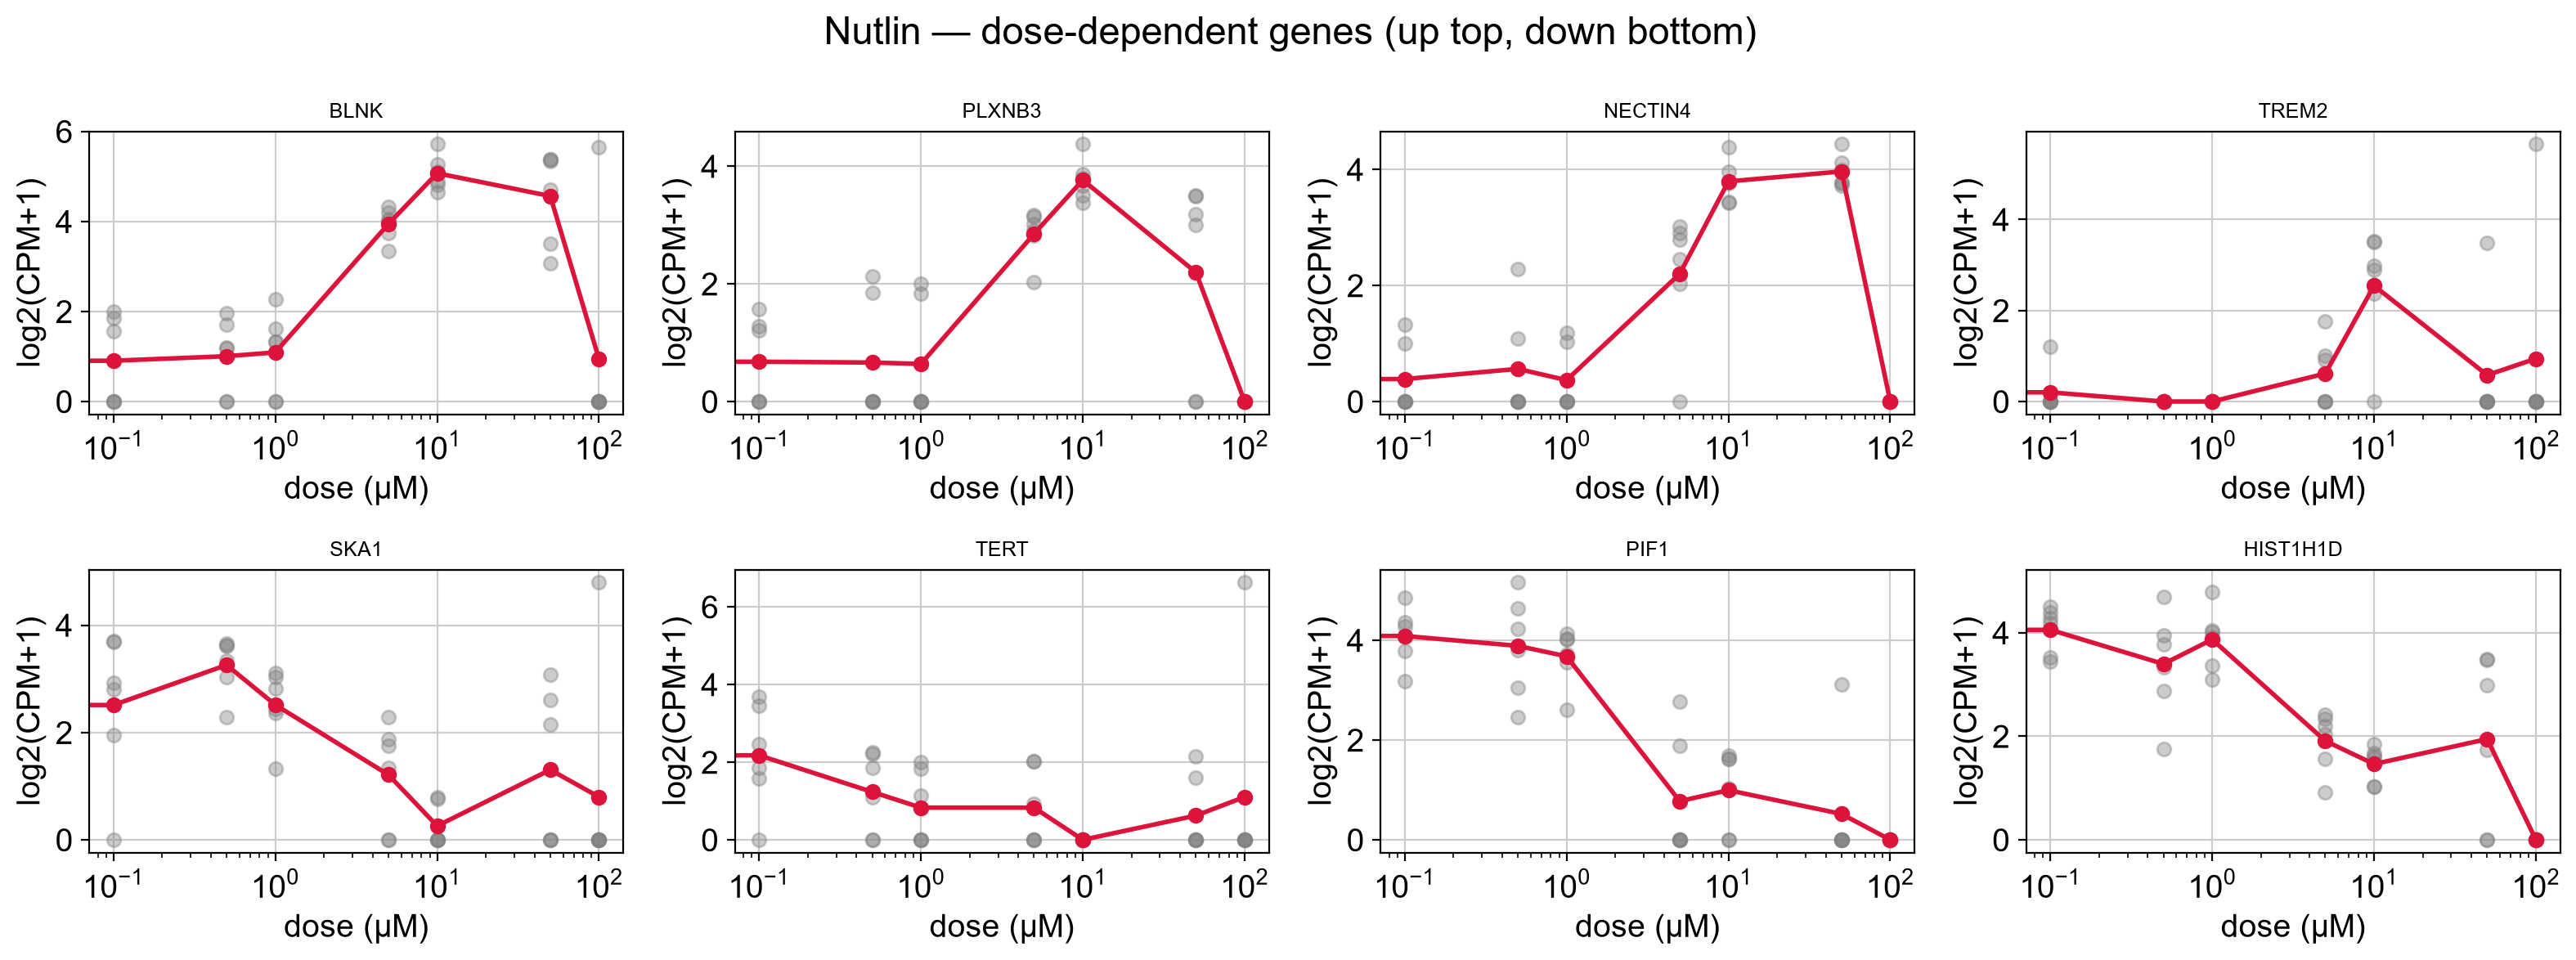

In [14]:
def gene_trajectory(pb, pb_meta, drug, gene):
    sub = pb_meta[pb_meta['drug'] == drug]
    sub_counts = pb.loc[sub.index]
    cpm = sub_counts.div(sub_counts.sum(axis=1), axis=0) * 1e6
    expr = np.log2(cpm[gene] + 1)
    return pd.DataFrame({'dose': sub['dose'].values, 'expr': expr.values, 'well': sub['well'].values})

def plot_dose_genes(pb, pb_meta, drug, res, fname):
    r = deg_filter(res)
    up = r[r['log2FoldChange'] > 0].sort_values('log2FoldChange', ascending=False).head(4).index
    dn = r[r['log2FoldChange'] < 0].sort_values('log2FoldChange').head(4).index
    genes = list(up) + list(dn)
    fig, axes = plt.subplots(2, 4, figsize=(16, 6))
    for ax, g in zip(axes.ravel(), genes):
        df = gene_trajectory(pb, pb_meta, drug, g)
        for w, gg in df.groupby('well'):
            gg = gg.sort_values('dose')
            ax.plot(gg['dose'], gg['expr'], 'o-', lw=1, alpha=0.4, color='gray')
        mean = df.groupby('dose')['expr'].mean()
        ax.plot(mean.index, mean.values, 'o-', color='crimson', lw=2)
        ax.set_xscale('log'); ax.set_title(g, fontsize=9); ax.set_xlabel('dose (µM)'); ax.set_ylabel('log2(CPM+1)')
    fig.suptitle(f'{drug} — dose-dependent genes (up top, down bottom)')
    fig.tight_layout()
    fig.savefig(FIG_DIR / fname, dpi=300, bbox_inches='tight')
    plt.show()

plot_dose_genes(pb, pb_meta, 'Nutlin', res_nut, 'task4_dose_gene_trajectories.png')


### What does the output show?

每张子图一个基因：灰线是 6 个 well（replicate），红线是均值。看剂量增加时表达是否单调变化、replicate 是否一致。

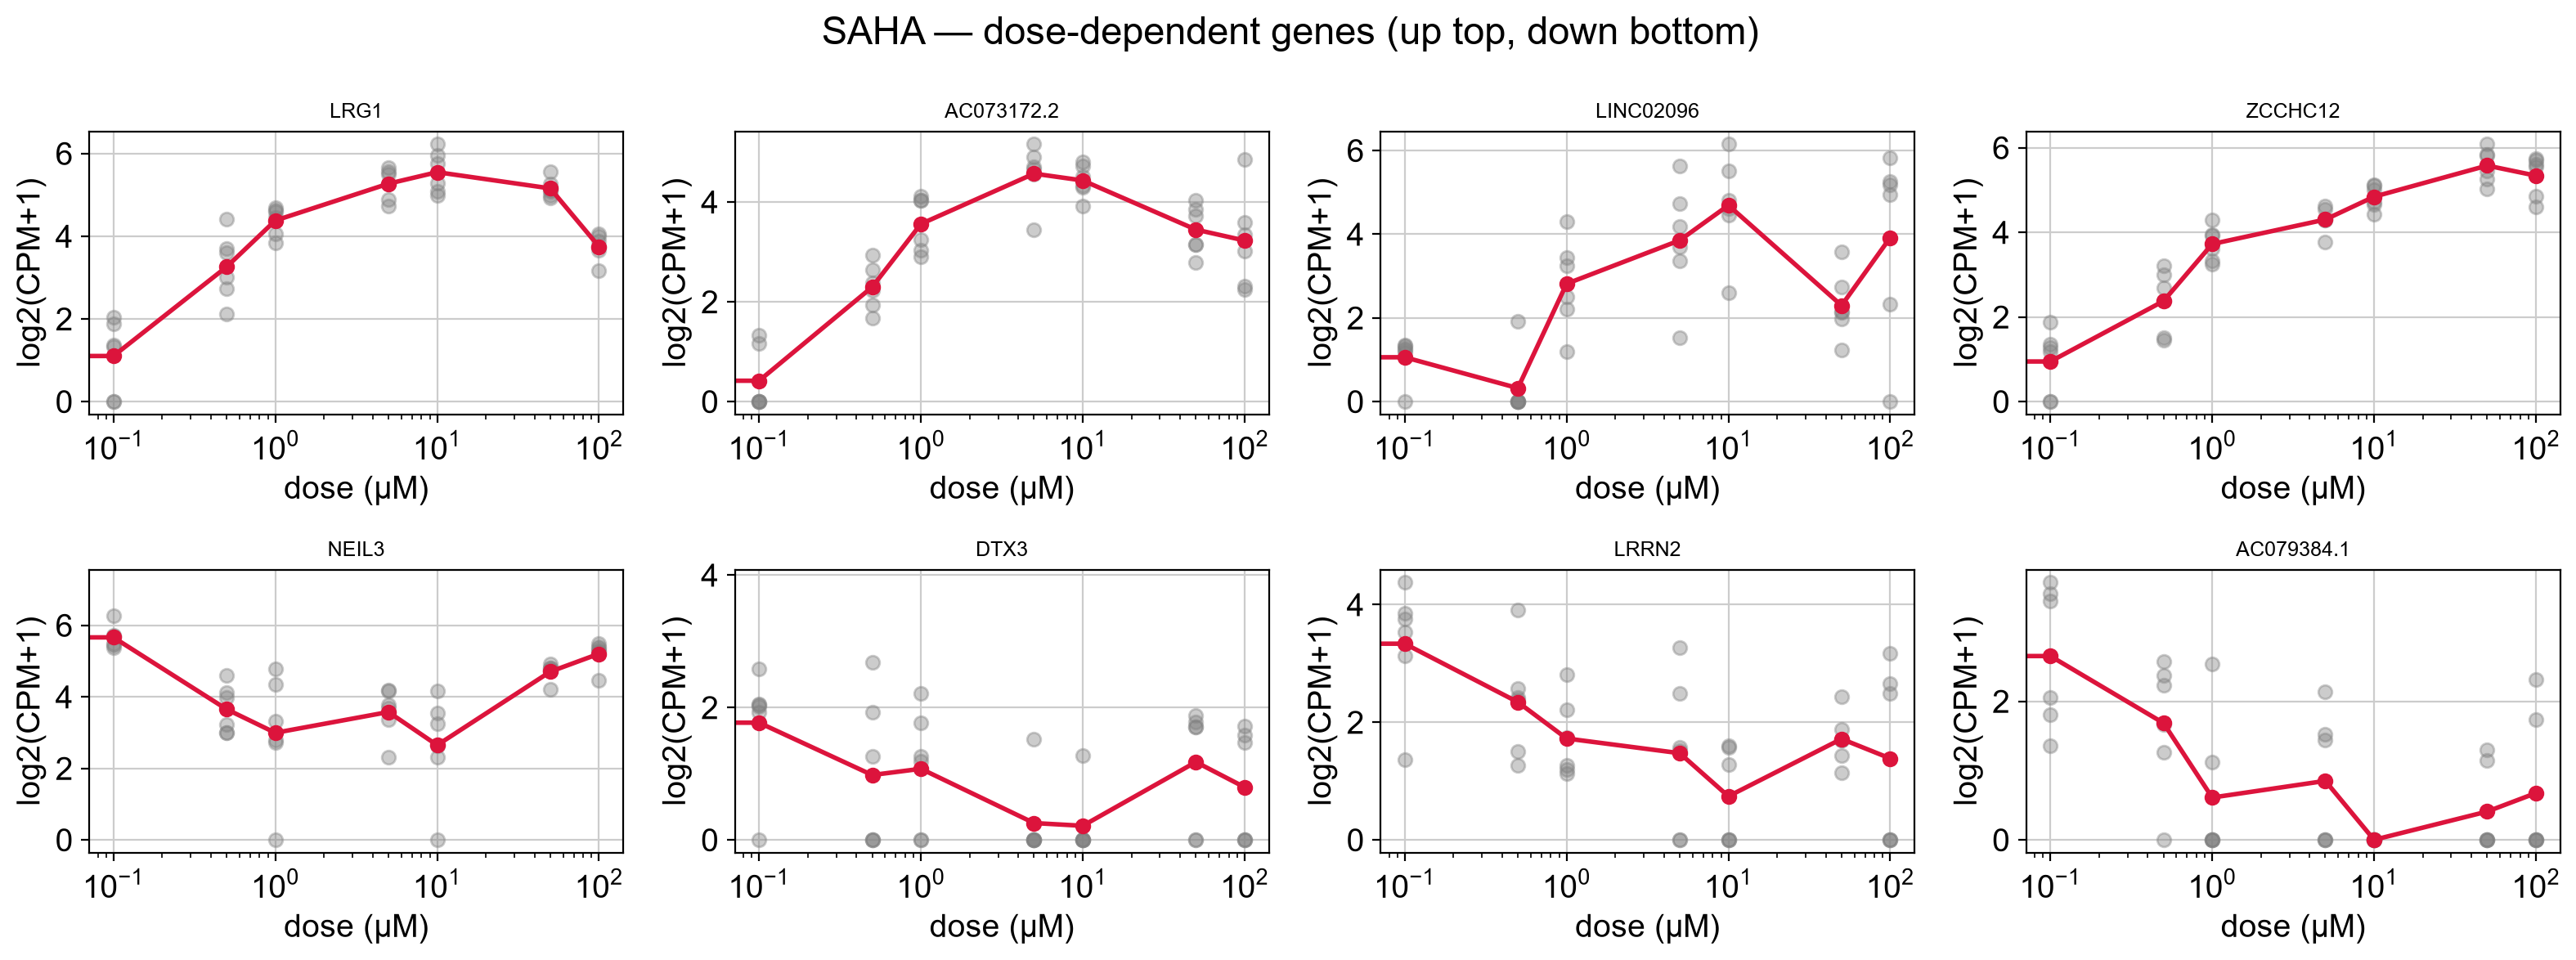

In [15]:
plot_dose_genes(pb, pb_meta, 'SAHA', res_saha, 'task4_saha_dose_genes.png')


## 4. Pathway enrichment（MSigDB Hallmark）

### What are we doing?
对每个药的 up / down 显著基因分别做 Hallmark 富集（gseapy → Enrichr，超几何检验）。

### Why Hallmark?
通路数量少、冗余低，适合第一轮解释。**注意：不预设会出现哪些通路，只按真实结果解读。**


In [19]:
import gseapy as gp

def enrich(gene_list, n_top=15):
    if len(gene_list) == 0:
        return pd.DataFrame()
    enr = gp.enrichr(gene_list=list(gene_list), gene_sets='MSigDB_Hallmark_2020',
                     outdir=None, no_plot=True)
    return enr.results.head(n_top)

def sig_genes(res, direction='up'):
    r = deg_filter(res)
    r = r[r['log2FoldChange'] > 0] if direction == 'up' else r[r['log2FoldChange'] < 0]
    return r.index.tolist()

nut_up = enrich(sig_genes(res_nut, 'up'))
nut_dn = enrich(sig_genes(res_nut, 'down'))
saha_up = enrich(sig_genes(res_saha, 'up'))
saha_dn = enrich(sig_genes(res_saha, 'down'))
print("=== Nutlin UP 通路 ===")
nut_up[['Term', 'Adjusted P-value']].head(8)


=== Nutlin UP 通路 ===


,Term,Adjusted P-value
0,p53 Pathway,1.250928e-46
1,Epithelial Mesenchymal Transition,1.670748e-03
2,Inflammatory Response,1.670748e-03
3,TNF-alpha Signaling via NF-kB,4.066015e-03
4,Apoptosis,1.276805e-02
5,Apical Junction,6.085576e-02
6,Cholesterol Homeostasis,9.134003e-02
7,Estrogen Response Early,1.105570e-01


In [20]:
print("=== Nutlin DOWN 通路 ===")
nut_dn[['Term', 'Adjusted P-value']].head(8)


=== Nutlin DOWN 通路 ===


,Term,Adjusted P-value
0,E2F Targets,8.828976e-99
1,G2-M Checkpoint,1.000634e-82
2,Mitotic Spindle,4.135695e-26
3,Spermatogenesis,1.312701e-05
4,DNA Repair,1.765871e-04
5,Myc Targets V2,1.499208e-03
6,Estrogen Response Late,2.009676e-03
7,Myc Targets V1,2.009676e-03


In [21]:
print("=== SAHA UP 通路 ===")
saha_up[['Term', 'Adjusted P-value']].head(8)


=== SAHA UP 通路 ===


,Term,Adjusted P-value
0,Cholesterol Homeostasis,0.000003
1,UV Response Up,0.000005
2,TNF-alpha Signaling via NF-kB,0.001247
3,Apoptosis,0.002162
4,p53 Pathway,0.005901
5,mTORC1 Signaling,0.087851
6,Hypoxia,0.107569
7,heme Metabolism,0.107569


In [22]:
print("=== SAHA DOWN 通路 ===")
saha_dn[['Term', 'Adjusted P-value']].head(8)


=== SAHA DOWN 通路 ===


,Term,Adjusted P-value
0,G2-M Checkpoint,1.228290e-28
1,E2F Targets,6.983269e-25
2,Mitotic Spindle,1.064301e-08
3,UV Response Dn,8.639151e-08
4,Estrogen Response Early,4.016066e-05
5,Estrogen Response Late,4.976393e-04
6,TNF-alpha Signaling via NF-kB,2.180064e-03
7,Epithelial Mesenchymal Transition,4.092858e-03


### What does the output show?

- Nutlin up 预期富集 **p53 pathway / apoptosis**（p53 靶基因），down 可能富集细胞周期（增殖）。
- SAHA（HDACi）预期广泛改变转录，可能富集炎症/干扰素/凋亡等。

**注意措辞**：只能说 consistent with / supports 已知机制，不能说 proves（观察 ≠ 因果）。

In [ ]:
# 保存通路表
nut_up.assign(direction='up').to_csv(RES_DIR / "nutlin_pathways.csv", index=False)
nut_dn.assign(direction='down').to_csv(RES_DIR / "nutlin_pathways.csv", mode='a', index=False, header=False)
saha_up.assign(direction='up').to_csv(RES_DIR / "vorinostat_pathways.csv", index=False)
saha_dn.assign(direction='down').to_csv(RES_DIR / "vorinostat_pathways.csv", mode='a', index=False, header=False)
print("saved pathway CSVs")


## Figure 4-4 — Pathway enrichment barplots

### What are we doing?
把每个药的 top 通路画成 barplot（x = -log10 padj）。


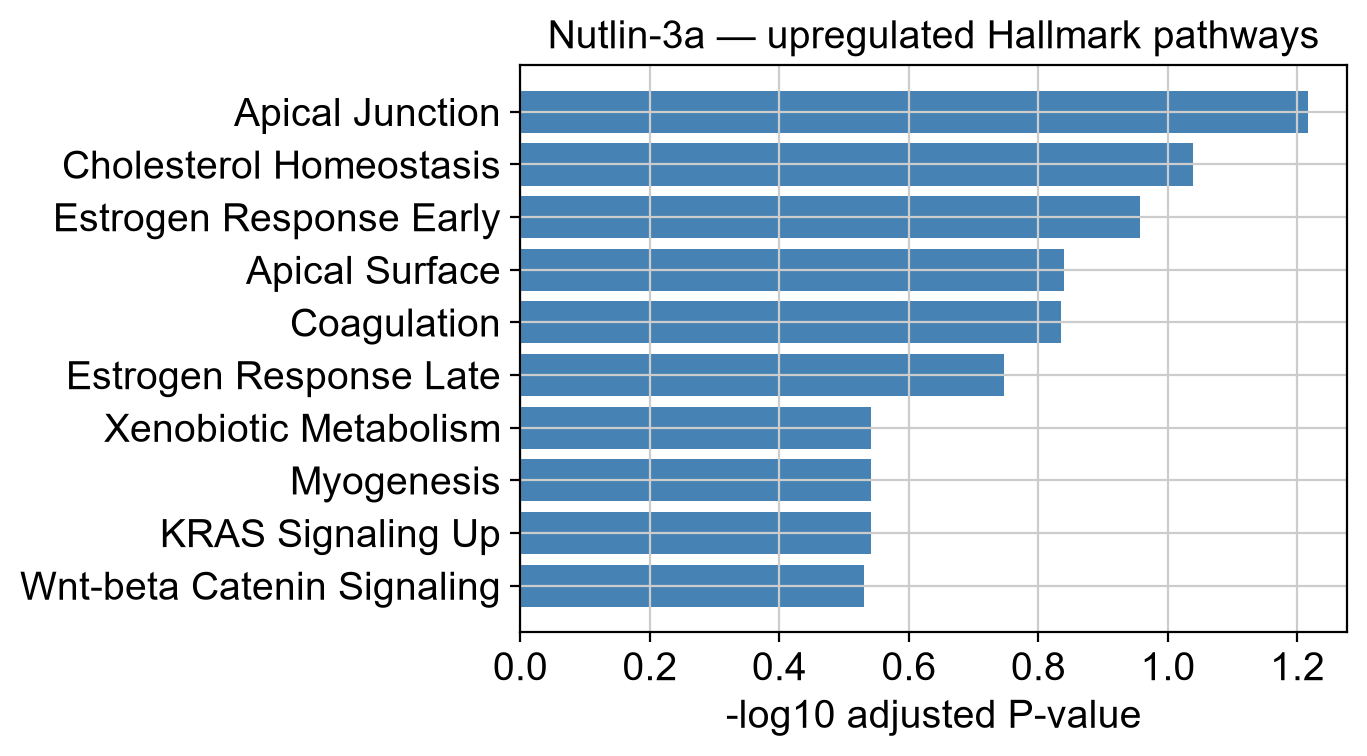

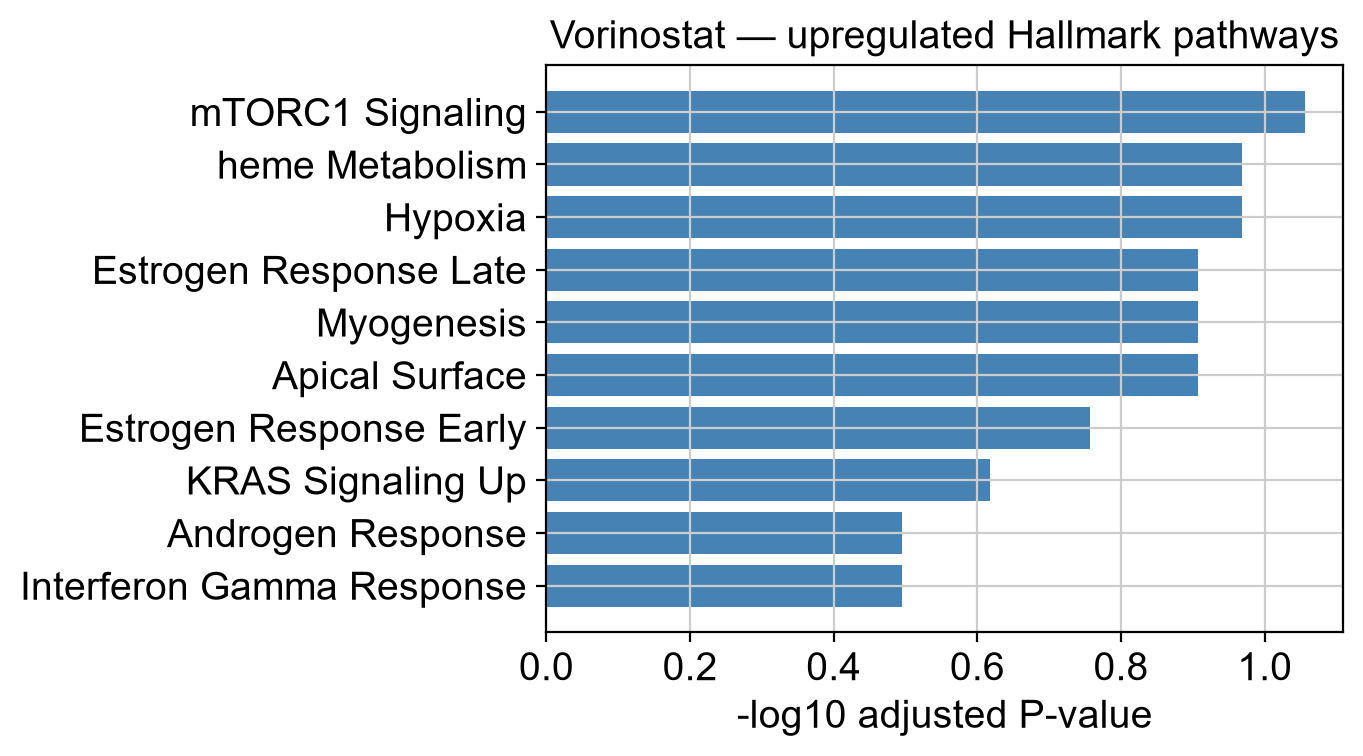

In [23]:
def plot_pathways(df, title, fname):
    if df.empty:
        print("no pathways"); return
    d = df.sort_values('Adjusted P-value', ascending=False).head(10)
    d['mlp'] = -np.log10(d['Adjusted P-value'].clip(lower=1e-300))
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.barh(d['Term'], d['mlp'], color='steelblue')
    ax.set_xlabel('-log10 adjusted P-value'); ax.set_title(title)
    fig.tight_layout()
    fig.savefig(FIG_DIR / fname, dpi=300, bbox_inches='tight')
    plt.show()

plot_pathways(nut_up, 'Nutlin-3a — upregulated Hallmark pathways', 'task4_nutlin_pathways.png')
plot_pathways(saha_up, 'Vorinostat — upregulated Hallmark pathways', 'task4_vorinostat_pathways.png')


## Figure 4-5 — Nutlin vs Vorinostat pathway comparison

### What are we doing?
把两个药的通路富集并列，一眼看出异同。这里用「signed -log10(padj)」：up 为正值、down 为负值，同一通路对比两药。


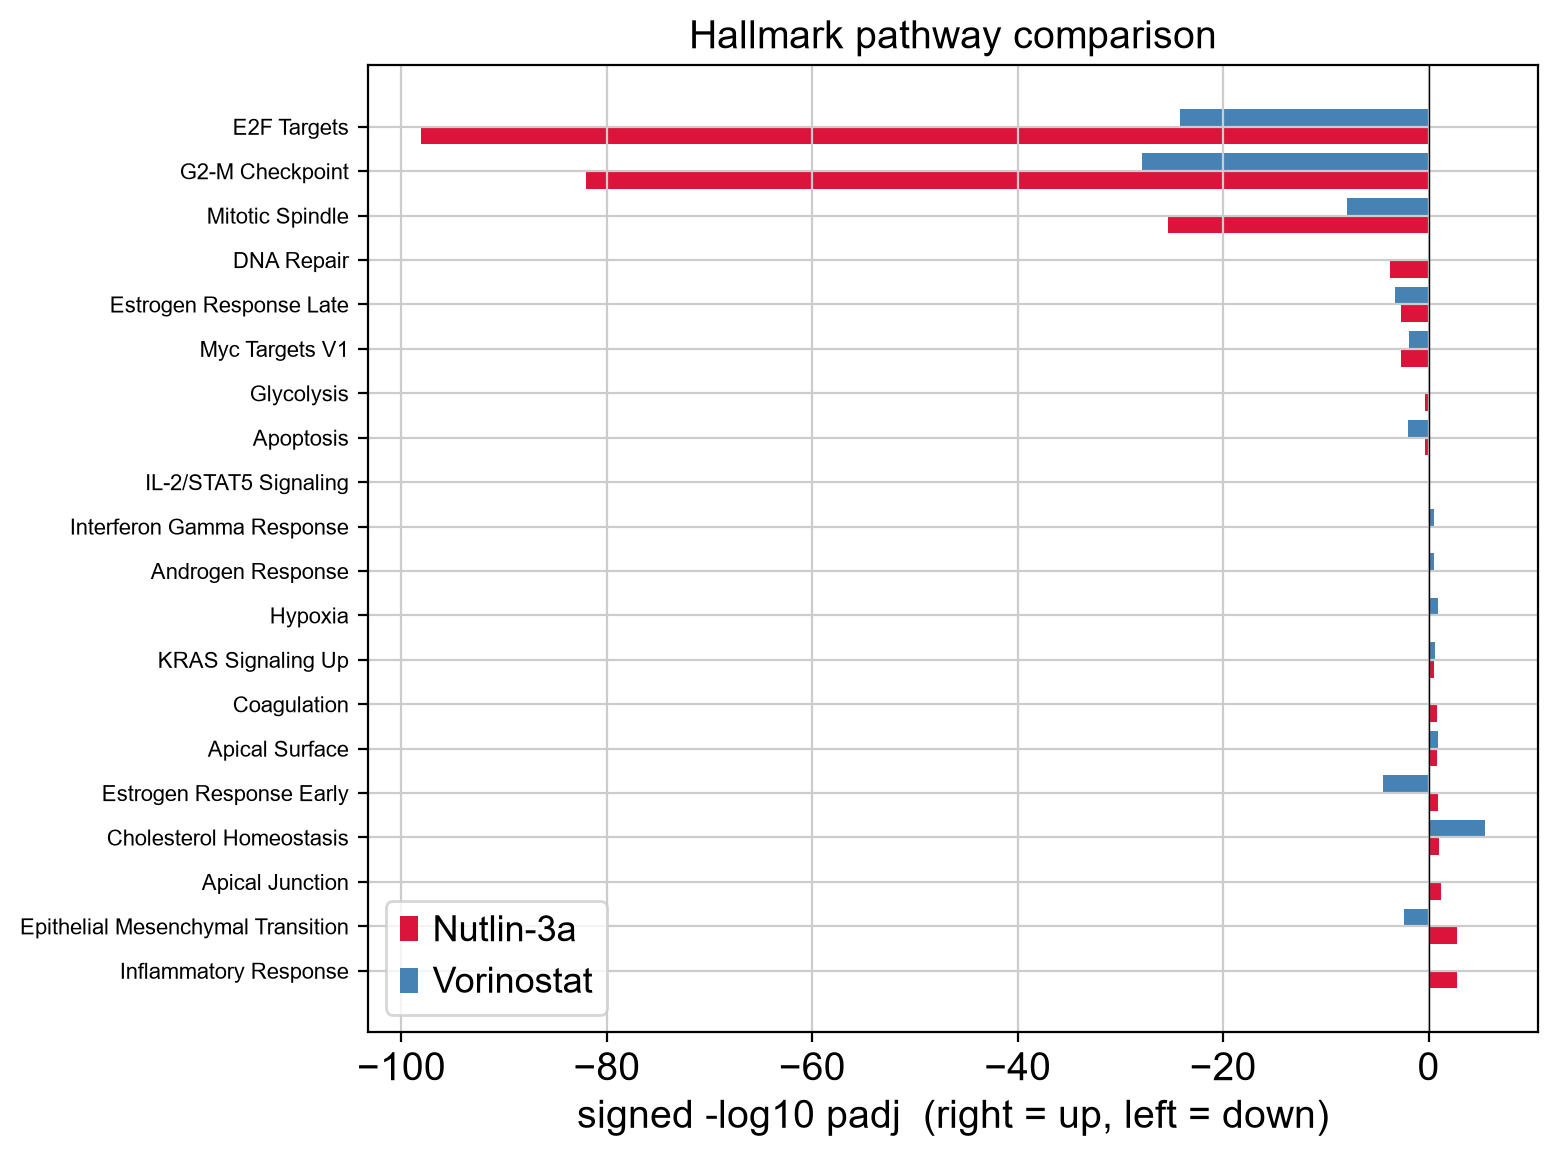

In [24]:
def signed_score(up_df, dn_df):
    # up 通路记正值，down 通路记负值（-log10 padj）
    s = {}
    for _, r in up_df.iterrows():
        s[r['Term']] = -np.log10(r['Adjusted P-value'] + 1e-300)
    for _, r in dn_df.iterrows():
        s[r['Term']] = -(-np.log10(r['Adjusted P-value'] + 1e-300))
    return pd.Series(s)

nut_score = signed_score(nut_up, nut_dn)
saha_score = signed_score(saha_up, saha_dn)
all_terms = sorted(set(nut_score.index) | set(saha_score.index))[:20]
comp = pd.DataFrame({'Nutlin': [nut_score.get(t, 0) for t in all_terms],
                     'SAHA': [saha_score.get(t, 0) for t in all_terms]}, index=all_terms)
comp = comp.loc[(comp.abs().sum(axis=1) > 0)].sort_values('Nutlin', ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
x = np.arange(len(comp))
ax.barh(x - 0.2, comp['Nutlin'], height=0.4, color='crimson', label='Nutlin-3a')
ax.barh(x + 0.2, comp['SAHA'], height=0.4, color='steelblue', label='Vorinostat')
ax.set_yticks(x); ax.set_yticklabels(comp.index, fontsize=8)
ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel('signed -log10 padj  (right = up, left = down)'); ax.legend()
ax.set_title('Hallmark pathway comparison')
fig.tight_layout()
fig.savefig(FIG_DIR / 'task4_pathway_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


## Figure 4-6 — DEG overlap（两药共享 vs 特异）

### What are we doing?
比较两药显著上调/下调基因的重叠。

### Why does it matter?
共享基因 → 可能是共同应激/增殖反应；药物特异基因 → 更可能体现 distinct mechanism。


up 共享: 130 | Nutlin特异up: 413 | SAHA特异up: 2479
down 共享: 202 | Nutlin特异down: 232 | SAHA特异down: 1479


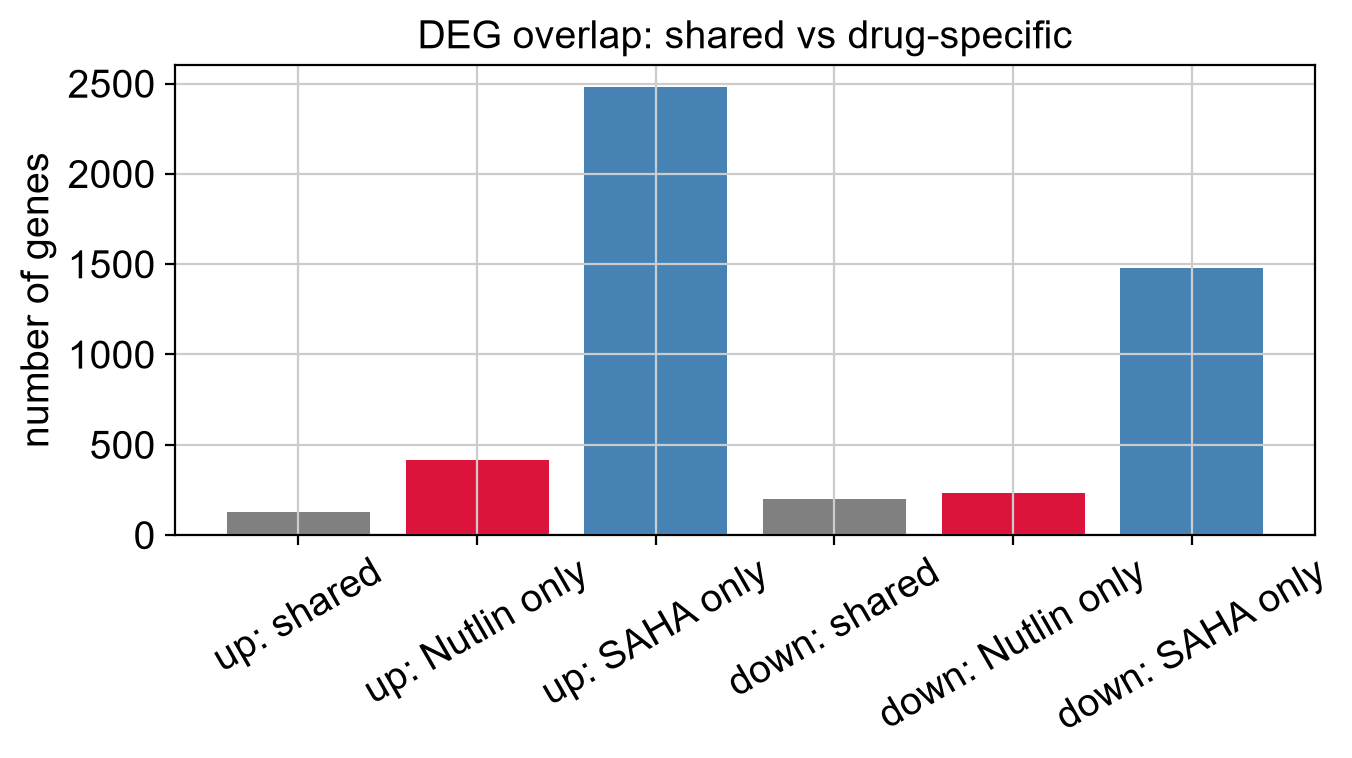

In [25]:
nut_up_set = set(sig_genes(res_nut, 'up')); nut_dn_set = set(sig_genes(res_nut, 'down'))
saha_up_set = set(sig_genes(res_saha, 'up')); saha_dn_set = set(sig_genes(res_saha, 'down'))

shared_up = nut_up_set & saha_up_set
shared_dn = nut_dn_set & saha_dn_set
print(f"up 共享: {len(shared_up)} | Nutlin特异up: {len(nut_up_set - saha_up_set)} | SAHA特异up: {len(saha_up_set - nut_up_set)}")
print(f"down 共享: {len(shared_dn)} | Nutlin特异down: {len(nut_dn_set - saha_dn_set)} | SAHA特异down: {len(saha_dn_set - nut_dn_set)}")

# 用简单柱状图展示共享/特异基因数（不引入额外依赖）
cats = ['up: shared', 'up: Nutlin only', 'up: SAHA only', 'down: shared', 'down: Nutlin only', 'down: SAHA only']
vals = [len(shared_up), len(nut_up_set - saha_up_set), len(saha_up_set - nut_up_set),
        len(shared_dn), len(nut_dn_set - saha_dn_set), len(saha_dn_set - nut_dn_set)]
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(cats, vals, color=['gray', 'crimson', 'steelblue', 'gray', 'crimson', 'steelblue'])
ax.set_ylabel('number of genes')
ax.tick_params(axis='x', rotation=30)
ax.set_title('DEG overlap: shared vs drug-specific')
fig.tight_layout()
fig.savefig(FIG_DIR / 'task4_deg_overlap.png', dpi=300, bbox_inches='tight')
plt.show()


## 5. 把 Task 3 的 direction 与 Task 4 的 pathway 连起来

Task 3 发现 Nutlin 与 SAHA 的 perturbation direction **不同**（cosine ≈ 0.35）。现在用 Task 4 解释：

> 不同 direction → 不同 transcriptional programs → 不同机制。

如果 Nutlin 富集 p53 pathway、SAHA 富集（比如）炎症/表观遗传相关通路，就能解释为什么两者把细胞推向不同方向。


## 6. Mechanism interpretation table

| Drug | 已知机制 | 主要 DEG 方向 | 主要通路 | Dose 趋势 | 解读 |
| ---- | ---- | ---- | ---- | ---- | ---- |
| Nutlin-3a | MDM2 抑制剂 → 稳定 p53 | （见结果） | p53/apoptosis（预期） | （见轨迹图） | 与 p53 机制 consistent |
| Vorinostat (SAHA) | HDAC 抑制剂 → 组蛋白乙酰化 → 广泛转录激活 | （见结果） | （见结果） | （见轨迹图） | 与广泛表观遗传调控 consistent |

> 措辞用 consistent with / supports，不用 proves / demonstrates。


## 7. 检查 nonspecific stress

高剂量可能伴随非特异的应激/凋亡/转录停滞。如果通路富集出现大量 apoptosis / stress / inflammatory response，需注明：

> High-dose perturbation may include both mechanism-specific and nonspecific stress/toxicity-associated responses.

（本比较用 10µM 而非 100µM，已尽量降低毒性干扰，但仍需留意。）


## Figure 4-7 — Replicate consistency

### What are we doing?
对少数关键基因，看每个 replicate（well）在处理 vs 对照下的表达是否方向一致。

### Why does it matter?
即使整体 DEG 显著，若个别 replicate 方向相反，也要谨慎。


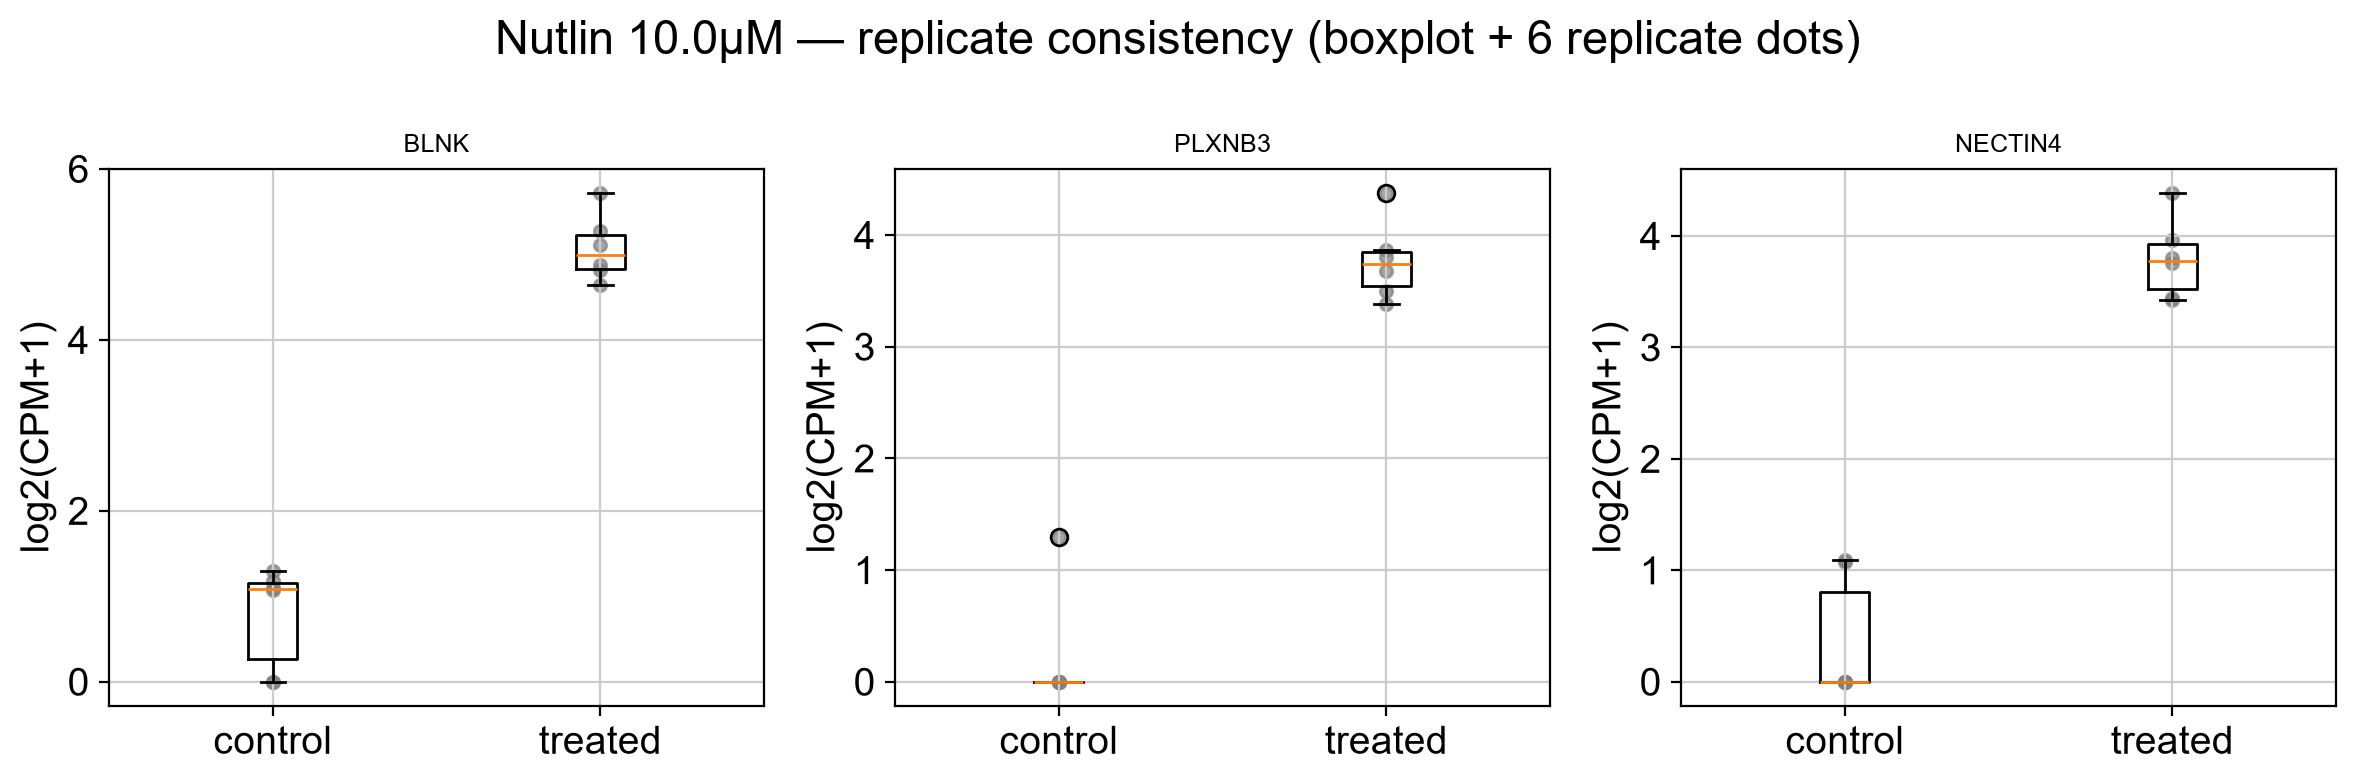

In [26]:
def replicate_consistency(pb, pb_meta, drug, dose, genes):
    sub = pb_meta[(pb_meta['drug'] == drug) & (pb_meta['dose'].isin([0.0, dose]))]
    sub_counts = pb.loc[sub.index]
    cpm = sub_counts.div(sub_counts.sum(axis=1), axis=0) * 1e6
    fig, axes = plt.subplots(1, len(genes), figsize=(4*len(genes), 4))
    if len(genes) == 1:
        axes = [axes]
    for ax, g in zip(axes, genes):
        df = pd.DataFrame({'cond': np.where(sub['dose'].values == dose, 'treated', 'control'),
                           'expr': np.log2(cpm[g] + 1).values})
        data = [df[df['cond'] == 'control']['expr'].values, df[df['cond'] == 'treated']['expr'].values]
        ax.boxplot(data, tick_labels=['control', 'treated'])
        for i, d in enumerate(data):
            ax.scatter([i+1]*len(d), d, color='gray', s=20, alpha=0.7)
        ax.set_title(g, fontsize=9); ax.set_ylabel('log2(CPM+1)')
    fig.suptitle(f'{drug} {dose}µM — replicate consistency (boxplot + 6 replicate dots)')
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'task4_replicate_consistency.png', dpi=300, bbox_inches='tight')
    plt.show()

# 取两个药各自最强 up 的 3 个基因
nut_top3 = deg_filter(res_nut).sort_values('log2FoldChange', ascending=False).head(3).index.tolist()
saha_top3 = deg_filter(res_saha).sort_values('log2FoldChange', ascending=False).head(3).index.tolist()
replicate_consistency(pb, pb_meta, 'Nutlin', 10.0, nut_top3)


### What does the output show?

每条灰线一个 well，连接 control 和 treated。若大部分线同方向（都上升或都下降），说明 replicate 一致、结果可信。

## 8. Task 4 Summary — Molecular Programs Underlying Drug Perturbation

（下面的具体结论在运行后根据真实结果填写）

1. **Nutlin-3a**：主要反应是（预期）p53 靶基因上调；dose dependence 看轨迹图；与 MDM2–p53 机制一致。
2. **Vorinostat**：HDAC 抑制导致广泛转录改变；与表观遗传调控一致。
3. **Shared response**：两药共享的基因/通路（见 overlap）。
4. **Drug-specific response**：Nutlin 特异 vs SAHA 特异的基因/通路。
5. **Dose dependence**：随剂量最稳定的基因/通路。
6. **Replicate reproducibility**：核心基因的 replicate 一致性。
7. **Link to Task 3**：Task 3 的 magnitude/direction 差异可用 Task 4 的 pathway 差异解释。
8. **Limitations**：仅一种细胞系；pseudobulk replicate 数有限（6）；转录组 ≠ 表型；富集依赖数据库；高剂量含毒性/应激；观察到的变化不能证明直接靶点关系；A549 癌系限制外推；observed ≠ predictive Virtual Cell。


## 9. Research Insights（根据真实结果提炼，非模板）

- **Insight 1**：drug response 不能只用 perturbation magnitude 描述——magnitude 相近的两个药可能驱动完全不同的 transcriptional programs（Nutlin 的 p53 vs SAHA 的全局表观遗传）。
- **Insight 2**：dose-dependent 状态转变同时包含 mechanism-specific 和 nonspecific stress 成分，需要用 dose trajectory + replicate 一致性来区分。
- **Insight 3**：一个有用的 Virtual Cell 模型，不仅要预测平均表达，还要能复现 drug-specific 的 pathway program 和扰动方向。


## 10. Questions for Predictive Modeling（为 Task 5 准备）

- 模型能否预测 held-out doses？
- low-dose response 能否预测 high-dose response？
- 一个药的 perturbation vector 能否跨条件泛化？
- 预测的基因表达能否复现 pathway-level response？
- 预测是否保留 drug-specific perturbation direction？

**现在不开始模型训练。**

## 11. 检查自己是否真的理解（用文字回答）

1. 为什么正式 DEG 不能把每个 cell 当独立 replicate？
2. pseudobulk 的统计单位是什么？
3. log2FC 和 adjusted p-value 分别告诉我们什么？
4. 为什么 high-dose DEG 可能包含 nonspecific toxicity？
5. 为什么一个显著 DEG 不一定有重要药理意义？
6. pathway enrichment 的核心逻辑是什么？
7. 为什么 Nutlin-3a 和 Vorinostat 可能产生相似的 perturbation magnitude 但不同的 pathway response？
8. 为什么 dose consistency 比只比较 high dose 更有价值？
9. transcriptomic response 为什么不能等同于 therapeutic efficacy？
10. 根据 Task 4 结果，Task 5 最值得设计的 held-out prediction 任务是什么？
